# SSP interpolation
## Load SSP Grid

In [1]:
# NBVAL_SKIP
from rubix.spectra.ssp.templates import BruzualCharlot2003

print(BruzualCharlot2003)


2025-11-10 17:13:20,829 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2025-11-10 17:13:20,831 - rubix - INFO - Rubix version: 0.0.post626+g42b4b7505.d20251110
2025-11-10 17:13:20,831 - rubix - INFO - JAX version: 0.7.2
2025-11-10 17:13:20,909 - rubix - INFO - Running on [CpuDevice(id=0)] devices
2025-11-10 17:13:20,911 - rubix - WARNING - python-fsps is not installed. Please install it to use this function. Install using pip install fsps and check the installation page: https://dfm.io/python-fsps/current/installation/ for more details. Especially, make sure to set all necessary environment variables.


HDF5SSPGrid(age=Array([ 0.       ,  5.100002 ,  5.1500006,  5.1999993,  5.25     ,
        5.3000016,  5.350002 ,  5.4000006,  5.4500012,  5.500002 ,
        5.550002 ,  5.600002 ,  5.6500025,  5.700002 ,  5.750002 ,
        5.8000026,  5.850003 ,  5.900003 ,  5.950003 ,  6.       ,
        6.0200005,  6.040001 ,  6.0599985,  6.0799985,  6.100002 ,
        6.120001 ,  6.1399984,  6.16     ,  6.18     ,  6.1999993,
        6.2200007,  6.24     ,  6.2599998,  6.2799997,  6.2999997,
        6.3199987,  6.3399997,  6.3600006,  6.3799996,  6.3999987,
        6.4200006,  6.44     ,  6.4599996,  6.4799995,  6.499999 ,
        6.52     ,  6.539999 ,  6.56     ,  6.5799994,  6.6      ,
        6.6199994,  6.6399994,  6.66     ,  6.679999 ,  6.699999 ,
        6.72     ,  6.7399993,  6.7599993,  6.7799997,  6.799999 ,
        6.819999 ,  6.839999 ,  6.8599997,  6.879999 ,  6.899999 ,
        6.919999 ,  6.939999 ,  6.959999 ,  6.9799986,  6.999999 ,
        7.0200005,  7.040001 ,  7.0599985,  7.

## SSP lookup

2.550001


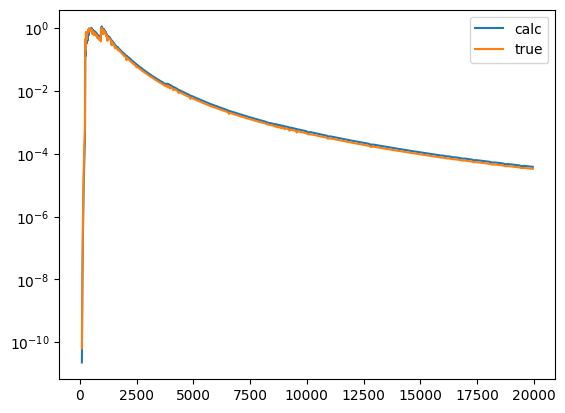

In [2]:
# NBVAL_SKIP
import matplotlib.pyplot as plt
from rubix.spectra.ssp.templates import BruzualCharlot2003
from jax import jit

ssp = BruzualCharlot2003
wave = ssp.wavelength


age_index = 0
met_index = 3

target_age = ssp.age[age_index] + 0.5*(ssp.age[age_index+1] - ssp.age[age_index])
print(target_age)
target_met = ssp.metallicity[met_index] + 0.5*(ssp.metallicity[met_index+1] - ssp.metallicity[met_index])

lookup = ssp.get_lookup_interpolation()

spec_calc = lookup(target_met, target_age)

spec_true = ssp.flux[met_index, age_index, :]

plt.plot(wave, spec_calc, label='calc')
plt.plot(wave, spec_true, label='true')

plt.legend()
plt.yscale('log')

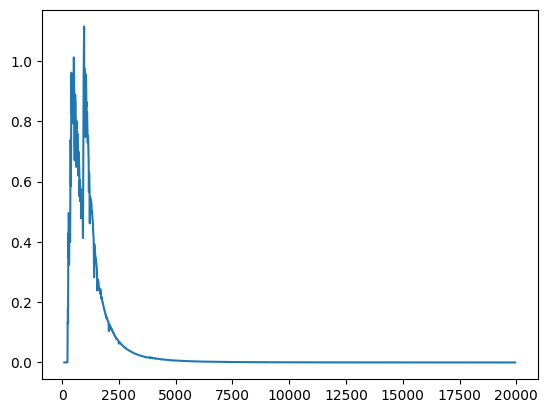

In [3]:
# NBVAL_SKIP
# Check if it works with jit

spec_calc = jit(lookup)(target_met, target_age)

plt.plot(wave, spec_calc, label='calc jit')

In [4]:
# NBVAL_SKIP
from rubix.utils import load_galaxy_data

data, units = load_galaxy_data("output/rubix_galaxy.h5")
mass = data["particle_data"]["stars"]["mass"]
metallicity = data["particle_data"]["stars"]["metallicity"]
age = data["particle_data"]["stars"]["age"]

## VMAP

Vmap the lookup over the stellar particles

In [5]:
# NBVAL_SKIP
# Calculate spectra with vmap
from jax import vmap

lookup = ssp.get_lookup_interpolation()

subset = 1000

# Use only subset because it is too big to fit into gpu memory
met_subset = metallicity[:subset]
age_subset = age[:subset]


# Clip the metallicity and age values to the range of the SSP

met_subset = met_subset.clip(min(ssp.metallicity), max(ssp.metallicity))
age_subset = age_subset.clip(min(ssp.age), max(ssp.age))


spec_calc = vmap(lookup)(met_subset, age_subset)


spec_calc.shape


(1000, 842)

In [6]:
# NBVAL_SKIP
# check if it contains nan values
import jax.numpy as jnp
jnp.isnan(spec_calc).any()

Array(False, dtype=bool)

# Use configuration to load lookup function

In [7]:
#NBVAL_SKIP
config ={ "ssp": {
    "template": {
      "name": "BruzualCharlot2003"
    },
    "method": "cubic"
  }
}

In [8]:
# NBVAL_SKIP
from rubix.core.ssp import get_lookup_interpolation

lookup = get_lookup_interpolation(config)

2025-11-10 17:13:25,095 - rubix - DEBUG - Using method defined in config: cubic


In [9]:
# NBVAL_SKIP
# Check how many particles are outside the range of the SSP
import numpy as np
np.sum(metallicity < ssp.metallicity[0]), np.sum(metallicity > ssp.metallicity[-1])

(Array(695, dtype=int32), Array(35669, dtype=int32))

In [10]:
# NBVAL_SKIP
np.sum(age < ssp.age[0]), np.sum(age > ssp.age[-1])

(Array(0, dtype=int32), Array(45331, dtype=int32))

In [11]:
# NBVAL_SKIP
len(metallicity)

643940

In [12]:
# NBVAL_SKIP
# clip the metallicity and age values to the range of the SSP
met_subset = met_subset.clip(min(ssp.metallicity), max(ssp.metallicity))
age_subset = age_subset.clip(min(ssp.age), max(ssp.age))
lookup(met_subset, age_subset)

Array([[ 0.0000000e+00,  2.7755576e-17,  5.5511151e-17, ...,
         4.5619352e-05,  4.4804754e-05,  4.3980177e-05],
       [ 0.0000000e+00,  2.7755576e-17,  5.5511151e-17, ...,
         4.5822202e-05,  4.5003901e-05,  4.4175598e-05],
       [ 0.0000000e+00,  2.7755576e-17,  5.5511151e-17, ...,
         4.8169481e-05,  4.7308338e-05,  4.6436926e-05],
       ...,
       [ 0.0000000e+00,  2.7755576e-17,  5.5511151e-17, ...,
         4.6039131e-05,  4.5216868e-05,  4.4384582e-05],
       [-5.2917185e-12, -1.3075374e-11, -2.3385127e-11, ...,
         4.5421279e-05,  4.4608027e-05,  4.3794011e-05],
       [ 0.0000000e+00,  2.7755576e-17,  5.5511151e-17, ...,
         4.4646134e-05,  4.3849301e-05,  4.3042593e-05]], dtype=float32)